In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Cargar datos
datos = pd.read_csv('./cama_oversampled.csv')  # Asegúrate de cambiar 'tu_archivo.csv' por el nombre de tu archivo de datos
X = datos.drop('cama', axis=1)  # Características
y = datos['cama']  # Variable objetivo

# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(500, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(200, activation='relu'),
    Dropout(0.5),
    Dense(1000, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=10)

In [ ]:
history = model.fit(X_train, y_train, epochs=200, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/200
3668/3668 [==============================] - 37s 10ms/step - loss: 0.4512 - accuracy: 0.7796 - val_loss: 0.3623 - val_accuracy: 0.8323
Epoch 2/200
3668/3668 [==============================] - 33s 9ms/step - loss: 0.3575 - accuracy: 0.8322 - val_loss: 0.2706 - val_accuracy: 0.8970
Epoch 3/200
3668/3668 [==============================] - 34s 9ms/step - loss: 0.3087 - accuracy: 0.8640 - val_loss: 0.2346 - val_accuracy: 0.9209
Epoch 4/200
3668/3668 [==============================] - 32s 9ms/step - loss: 0.2806 - accuracy: 0.8805 - val_loss: 0.1914 - val_accuracy: 0.9409
Epoch 5/200
3668/3668 [==============================] - 34s 9ms/step - loss: 0.2666 - accuracy: 0.8894 - val_loss: 0.1781 - val_accuracy: 0.9414
Epoch 6/200
3668/3668 [==============================] - 32s 9ms/step - loss: 0.2566 - accuracy: 0.8948 - val_loss: 0.1636 - val_accuracy: 0.9537
Epoch 7/200
3668/3668 [==============================] - 34s 9ms/step - loss: 0.2456 - accuracy: 0.8995 - val_loss: 0.1780 

In [ ]:
model.evaluate(X_test, y_test)

1147/1147 [==============================] - 3s 2ms/step - loss: 0.1262 - accuracy: 0.9583


[0.12624751031398773, 0.9582606554031372]

In [ ]:
from sklearn.metrics import f1_score

# Realizar predicciones
predictions = model.predict(X_test)
predictions = (predictions > 0.5).astype(int)  # Convertir las probabilidades a etiquetas binarias

# Calcular F1 score
f1 = f1_score(y_test, predictions)
print(f'F1 Score: {f1}')

1147/1147 [==============================] - 4s 3ms/step
F1 Score: 0.9585330841526503


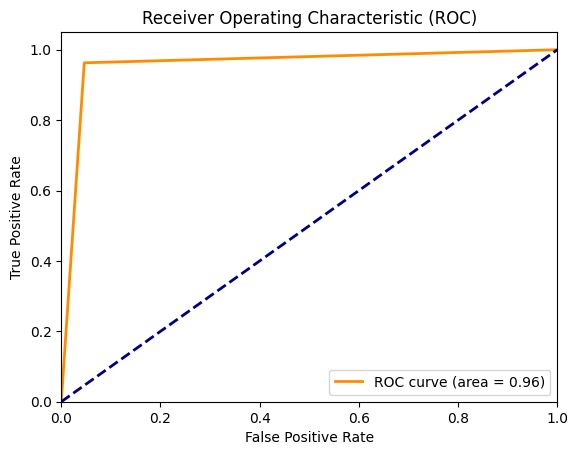

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calcular las tasas de verdaderos y falsos positivos
fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Calcular el área bajo la curva ROC
roc_auc = auc(fpr, tpr)

# Gráfica de la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
model.save('model_cama.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
